In [2]:
#导入包
import cv2
import numpy as np
import matplotlib.pyplot as plt

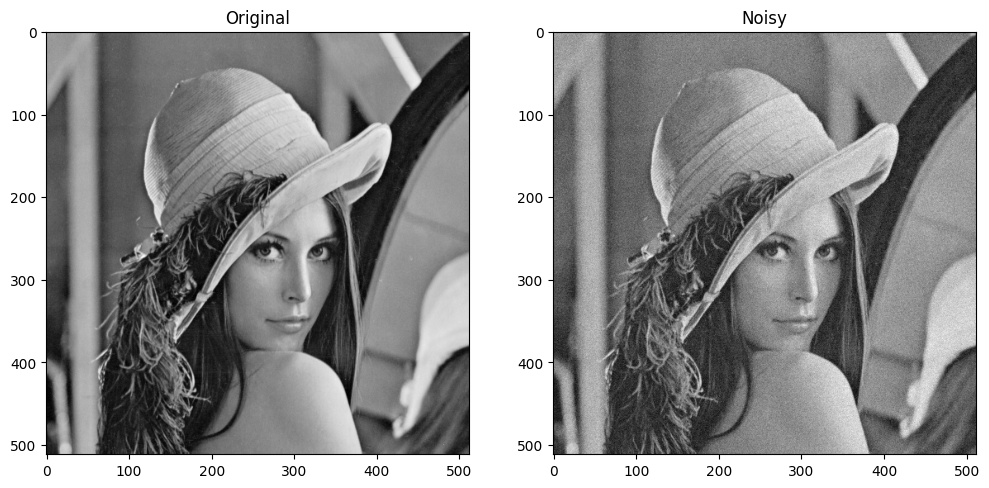

In [24]:
#读取图像＋加噪
img = cv2.imread('lenna.jpg',0)
sigma = 10
img_noisy = img + sigma * np.random.randn(*img.shape)
plt.figure(figsize=(12, 16))
plt.subplot(1,2,1), plt.imshow(img,cmap='gray'), plt.title('Original')
plt.subplot(1,2,2), plt.imshow(img_noisy,cmap='gray'), plt.title('Noisy')
plt.show()

In [52]:
#权重函数w(p,q)
def make_kernel(sim_rad):
    """
    parameter sim_rad: 相似窗半径
    output kernel: 权重函数 shape=(2*sim_rad+1, 2*sim_rad+1)
    """
    #初始化权重矩阵W
    kernel = np.zeros((2*sim_rad+1,2*sim_rad+1),dtype=np.float32)
    for d in range(0, sim_rad+1):
        value = 1 / (2 * d + 1) ** 2
        for i in range(-d, d+1):
            for j in range(-d, d+1):
                kernel[sim_rad-i, sim_rad-j] += value
    kernel = kernel/np.sum(kernel)
    return kernel

#NLM去噪核心
def nlm_filter(img_noisy, search_rad, sim_rad, h):
    """
    parameter img_noisy: 加噪图像
    parameter search_rad: 搜索窗半径
    parameter sim_rad: 相似窗半径
    parameter h: 滤波参数
    output img_clean: 去噪图像
    """
    #图像预处理(类型转换+填充)
    img_noisy = np.float32(img_noisy)
    img_clean = np.zeros_like(img_noisy)
    m,n = img_noisy.shape
    #图像填充(针对边缘部分)
    pad_size = sim_rad 
    img_pad = np.pad(img_noisy, sim_rad, mode='symmetric')
    kernel = make_kernel(sim_rad)
    for i in range(m):
        for j in range(n):
            i_pad = i + pad_size
            j_pad = j + pad_size
            #确定相似块p 和 搜索范围Ω的四个顶点
            current_block = img_pad[i_pad-sim_rad:i_pad+sim_rad+1,
                                    j_pad-sim_rad:j_pad+sim_rad+1]
            search_i_min = max(i_pad-search_rad, sim_rad)
            search_i_max = min(i_pad+search_rad, m+sim_rad-1)
            search_j_min = max(j_pad-search_rad, sim_rad)
            search_j_max = min(j_pad+search_rad, n+sim_rad-1)
            
            weight_sum = 0.0
            pixel_sum = 0.0
            max_weight = 0.0 # 相似窗和像素块重合，weight=1.如果不排除重合情况，边缘部分像素weight在1e-8量级，悬殊极大
            #遍历搜索范围
            for x in range(search_i_min,search_i_max+1):
                for y in range(search_j_min,search_j_max+1):
                    if x==i_pad and y==j_pad:
                        continue
                    sim_block = img_pad[x-sim_rad:x+sim_rad+1,
                                        y-sim_rad:y+sim_rad+1]
                    diff = current_block - sim_block
                    distance = np.sum(kernel * diff * diff)
                    weight = np.exp(-distance / h**2)
                    weight_sum += weight
                    pixel_sum += weight * img_pad[x,y]
                    if weight>max_weight:
                        max_weight = weight  
            pixel_sum += max_weight * img_pad[i_pad,j_pad]
            weight_sum += max_weight
            img_clean[i,j] = pixel_sum / weight_sum if weight_sum > 1e-12 else img_noisy[i,j]
    return img_clean

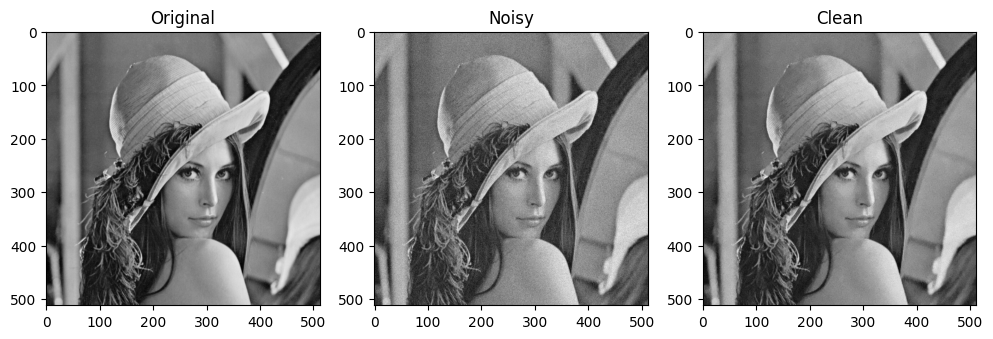

In [53]:
#主函数
search_rad = 5
sim_rad = 2
h = 10
img_clean = nlm_filter(img_noisy, search_rad, sim_rad, h)
plt.figure(figsize=(12, 18))
plt.subplot(1,3,1), plt.imshow(img,cmap='gray'), plt.title('Original')
plt.subplot(1,3,2), plt.imshow(img_noisy,cmap='gray'), plt.title('Noisy')
plt.subplot(1,3,3), plt.imshow(img_clean,cmap='gray'), plt.title('Clean')
plt.show()

In [ ]:
t = np.linspace(0, 1, 400, endpoint=True)
cond = [t<0.4, t>=0.4]
# print(f'cond = {cond}')
print(cond[0][0:50],cond[1][0:50])

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True False False False False Fa